# Simulação Educativa da PDDE (NEWAVE Simplificado)

Este notebook simula a lógica da Programação Dinâmica Dual Estocástica (PDDE), usada no modelo NEWAVE.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange

### Funções

In [2]:
def verificacao_dadger(dadger: dict):
    """Verifica se os dados do sistema estão corretos

    Args:
        dadger (dict): dicionário com dados do sistema
    """
    assert dadger["estagios"] > 0, "Número de estágios deve ser maior que zero."
    assert dadger["estagios"] == len(dadger["UHE"]["afluencias"]), (
        "Número de afluências deve ser igual ao número de estágios."
    )
    assert len(dadger["UHE"]["probabilidade"]) == len(dadger["UHE"]["afluencias"]), (
        "Número probabilidades de afluências deve ser igual ao número de afluências."
    )
    assert dadger["estagios"] == len(dadger["demanda"]), (
        "Número de demandas deve ser igual ao número de estágios."
    )

#### Otimização

In [3]:
def gerar_afluencias(n: int = 5, afl_max: int = 5, seed: int = None):
    """
    Gera n afluências aleatórias entre 0 e 5.

    Args:
        n (int): Número de cenários. Default = 5
        seed (int): Semente opcional para reprodutibilidade
    """
    if seed is not None:
        np.random.seed(seed)

    afluencias = np.random.randint(0, afl_max, size=n)
    # print(f'Afluências: {afluencias}')
    return afluencias


def gerar_probabilidades(n: int = 5, seed=None):
    """
    Gera n probabilidades (somando 1).

    Args:
        n (int): Número de cenários. Default = 5
        seed (int): Semente opcional para reprodutibilidade
    """
    if seed is not None:
        np.random.seed(seed)

    probabilidades = np.random.dirichlet(np.ones(n))
    # print(f'Probabilidades: {probabilidades}')
    return probabilidades

In [4]:
def inicializar_fcf(dadger: dict) -> list[dict]:
    """Inicialização da FCF do último estágio

    Args:
        dadger (dict): _description_

    Returns:
        _type_: _description_
    """
    # Inicialização da FCF no último estágio
    fcf = [{} for _ in range(dadger["estagios"] + 1)]  # fcf[estagio][volume] = custo esperado

    afluencias = gerar_afluencias(n=dadger["estagios"], seed=dadger.get("seed"))
    probabilidades = gerar_probabilidades(n=dadger["estagios"], seed=dadger.get("seed"))

    for v in range(0, dadger["UHE"]["vol_max"] + 1):
        custo_esperado = 0
        for a, p, d in zip(afluencias, probabilidades, dadger["demanda"]):
            vol_disp = min(v + a, dadger["UHE"]["turb_max"])
            energia_hid = vol_disp

            complementacao_termica = max(0, d - energia_hid)
            energia_termicas = []
            custo_termicas = 0

            for gt_max, cvu in sorted(
                zip(dadger["UTE"]["gt_max"], dadger["UTE"]["cvu"]), key=lambda x: x[1]
            ):
                energia = min(complementacao_termica, gt_max)
                energia_termicas.append(energia)
                custo_termicas += energia * cvu
                complementacao_termica -= energia

            deficit = max(0, complementacao_termica)
            custo_total = custo_termicas + deficit * dadger["custo_deficit"]

            custo_esperado += p * custo_total  # custo esperado é ponderado pela probabilidade do cenário
        fcf[dadger["estagios"]][v] = custo_esperado

    return fcf

In [5]:
def backward(dadger: dict, fcf: list) -> tuple[list, list[dict]]:
    """Criação da FCF utilizando o método backward

    Args:
        dadger (dict): _description_
        fcf (list): _description_

    Returns:
        _type_: _description_
    """
    # Backward nos estágios anteriores + salvar cortes
    cortes = [{} for _ in range(0, dadger["estagios"])]

    # dict_afluencias = {}

    for t in range(dadger["estagios"] - 1, 0, -1):
        print(f'Estágio {t}')
        # dict_afluencias[t] = {}

        # ! sorteio cenários backward -> não equiprováveis
        afluencias = gerar_afluencias(n=dadger["estagios"], seed=dadger.get("seed"))
        probabilidades = gerar_probabilidades(n=dadger["estagios"], seed=dadger.get("seed"))

        # dict_afluencias[t]['afluencias'] = afluencias
        # dict_afluencias[t]['probabilidades'] = probabilidades

        print(f'Afluências: {afluencias}')
        print(f'Probabilidades: {probabilidades}')
        print()

        for v in range(dadger["UHE"]["vol_max"] + 1):
            melhor_custo = float("inf")
            for turb in range(min(v, dadger["UHE"]["turb_max"]) + 1):
                for a, p, d in zip(
                    afluencias, probabilidades, dadger["demanda"]
                ):
                    v_futuro = min(max(0, v - turb + a), dadger["UHE"]["vol_max"])
                    energia_hid = turb

                    complementacao_termica = max(0, d - energia_hid)
                    energia_termicas = []
                    custo_termicas = 0

                    for gt_max, custo_unit in sorted(
                        zip(dadger["UTE"]["gt_max"], dadger["UTE"]["cvu"]), key=lambda x: x[1]
                    ):
                        energia = min(complementacao_termica, gt_max)
                        energia_termicas.append(energia)
                        custo_termicas += energia * custo_unit
                        complementacao_termica -= energia

                    deficit = max(0, complementacao_termica)
                    custo_atual = custo_termicas + deficit * dadger["custo_deficit"]

                    custo_futuro = fcf[t + 1][v_futuro]
                    custo_total = (
                        custo_atual + custo_futuro * p
                    )  # custo total é ponderado pela probabilidade do cenário

                    melhor_custo = min(melhor_custo, custo_total)

            fcf[t][v] = melhor_custo

        for v in range(1, dadger["UHE"]["vol_max"]):
            dy = fcf[t][v + 1] - fcf[t][v - 1]
            dx = 2
            slope = dy / dx
            intercept = fcf[t][v] - slope * v
            cortes[t][v] = (slope, intercept)

    return fcf, cortes

In [6]:
def forward(dadger: dict, fcf: list, seed: int = None) -> list:
    """Realiza simulação fazendo uso da FCF construída pelo

    Args:
        dadger (dict): _description_
        fcf (list): _description_

    Returns:
        list: _description_
    """
    if not seed:
        np.random.seed(dadger.get("seed"))
    else:
        np.random.seed(42)

    resultados = []
    v = dadger["UHE"]["vol_ini"]
    for t in range(1, dadger["estagios"] + 1):

        # ! sorteio cenários forward -> equiprováveis
        a = np.random.choice(dadger["UHE"]["afluencias"], p=dadger["UHE"]["probabilidade"])

        melhor = {"custo": float("inf")}
        for turb in range(min(v, dadger["UHE"]["turb_max"]) + 1):
            energia_hid = turb
            falta = max(0, dadger["demanda"][t - 1] - energia_hid)
            ger_T1 = min(falta, dadger["UTE"]["gt_max"][0])
            ger_T2 = min(falta - ger_T1, dadger["UTE"]["gt_max"][1])
            deficit = max(0, falta - ger_T1 - ger_T2)
            custo = (
                (ger_T1 * dadger["UTE"]["cvu"][0])
                + (ger_T2 * dadger["UTE"]["cvu"][1])
                + (deficit * dadger["custo_deficit"])
            )
            v_futuro = min(max(0, v - turb + a), dadger["UHE"]["vol_max"])
            if t < dadger["estagios"]:
                custo += fcf[t + 1][v_futuro]
            if custo < melhor["custo"]:
                melhor = {
                    "estagio": t,
                    "vol_inicial": v,
                    "afluencia": a,
                    "turb": turb,
                    "hid": energia_hid,
                    "T1": ger_T1,
                    "T2": ger_T2,
                    "deficit": deficit,
                    "custo": custo,
                    "vol_futuro": v_futuro,
                }
        resultados.append(melhor)
        v = melhor["vol_futuro"]
    return resultados

In [7]:
def monte_carlo(dadger: dict, fcf: list, n_simulacoes: int = 1000) -> tuple:
    """Aplica método de Monte Carlo para cálculo de valor esperado

    Args:
        dadger (dict): _description_
        fcf (list): _description_
        n_simulacoes (int, optional): _description_. Defaults to 1000.

    Returns:
        tuple: _description_
    """
    volumes = np.zeros((n_simulacoes, dadger["estagios"]))
    custos = np.zeros(n_simulacoes)
    for s in trange(n_simulacoes):
        resultado = forward(dadger, fcf, seed=s)
        for t, r in enumerate(resultado):
            volumes[s, t] = r["vol_inicial"]
        custos[s] = sum([r["custo"] for r in resultado])
    return volumes, custos

#### Viz

In [8]:
# Funções de visualização
def plot_cortes(dadger: dict, estagio: int, cortes: list, fcf: list):
    """_summary_

    Args:
        dadger (dict): _description_
        estagio (int): _description_
        cortes (list): _description_
        fcf (list): _description_
    """
    if estagio >= dadger["estagios"]:
        print(f"Não há cortes no estágio {estagio}. Estágio terminal.")
        return
    v_range = np.arange(0, dadger["UHE"]["vol_max"] + 1)
    f_range = [fcf[estagio][v] for v in v_range]
    plt.figure(figsize=(8, 5))
    plt.plot(v_range, f_range, label="FCF", lw=2)
    for v, (slope, intercept) in cortes[estagio].items():
        linha = slope * v_range + intercept
        plt.plot(v_range, linha, "--", alpha=0.6, label=f"Corte v={v}")
    plt.xlabel("Volume (hm³)")
    plt.ylabel("Custo esperado (R$)")
    plt.title(f"Cortes de Benders – Estágio {estagio}")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_cmo(dadger: dict, estagio: int, cortes: list):
    """_summary_

    Args:
        dadger (dict): _description_
        estagio (int): _description_
        cortes (list): _description_
    """
    if estagio >= dadger["estagios"]:
        print(f"Não é possível calcular CMO no estágio {estagio}.")
        return
    volumes = sorted(cortes[estagio].keys())
    cmo = [cortes[estagio][v][0] for v in volumes]
    plt.figure(figsize=(8, 4))
    plt.plot(volumes, cmo, marker="o")
    plt.title(f"Custo Marginal da Água – Estágio {estagio}")
    plt.xlabel("Volume (hm³)")
    plt.ylabel("CMO (R$/MWh)")
    plt.grid(True)
    plt.show()


# Gráficos da política ótima
def plot_forward(resultados: list):
    """_summary_

    Args:
        resultados (list): _description_
    """
    estagios = [r["estagio"] for r in resultados]
    turb = [r["hid"] for r in resultados]
    t1 = [r["T1"] for r in resultados]
    t2 = [r["T2"] for r in resultados]
    deficit = [r["deficit"] for r in resultados]
    custo = [r["custo"] for r in resultados]

    _, axs = plt.subplots(2, 2, figsize=(12, 8))
    axs[0, 0].bar(estagios, turb, color="blue")
    axs[0, 0].set_title("Geração Hidráulica por Estágio")
    axs[0, 1].bar(estagios, t1, color="orange", label="T1")
    axs[0, 1].bar(estagios, t2, bottom=t1, color="red", label="T2")
    axs[0, 1].set_title("Geração Térmica por Estágio")
    axs[0, 1].legend()
    axs[1, 0].bar(estagios, deficit, color="black")
    axs[1, 0].set_title("Déficit por Estágio")
    axs[1, 1].bar(estagios, custo, color="green")
    axs[1, 1].set_title("Custo Total por Estágio")
    plt.tight_layout()
    plt.show()


def plot_volumes(volumes):
    """_summary_

    Args:
        volumes (_type_): _description_
    """
    media = np.mean(volumes, axis=0)
    for s in range(min(100, len(volumes))):
        plt.plot(range(1, volumes.shape[1] + 1), volumes[s], color="lightgray", alpha=0.4)
    plt.plot(range(1, volumes.shape[1] + 1), media, color="blue", label="Média", linewidth=2)
    plt.title("Monte Carlo – Caminho dos Volumes")
    plt.xlabel("Estágio")
    plt.ylabel("Volume (hm³)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Dados do Sistema


In [9]:
# Dados do sistema
seed = 42

dadger = {}

dadger["estagios"] = 5

## UHE
dadger["UHE"] = {}
dadger["UHE"]["vol_max"] = 10
dadger["UHE"]["vol_ini"] = 5
dadger["UHE"]["turb_max"] = 5
dadger["UHE"]["afluencias"] = [5, 2, 0, 1, 3]  # forward
dadger["UHE"]["probabilidade"] = [0.2] * 5  # cenários equiprováveis

## UTE
dadger["UTE"] = {}
dadger["UTE"]["gt_max"] = [5, 8]
dadger["UTE"]["cvu"] = [100, 300]

## Demanda e déficit
dadger["demanda"] = [6, 8, 10, 12, 10]
dadger["custo_deficit"] = 1000

In [10]:
verificacao_dadger(dadger)

### Política


In [11]:
fcf = inicializar_fcf(dadger)

In [12]:
fcf, cortes = backward(dadger, fcf)

Estágio 4
Afluências: [4 4 3 1 0]
Probabilidades: [0.56805106 0.02113015 0.37700279 0.02742673 0.00638927]

Estágio 3
Afluências: [2 3 4 3 4]
Probabilidades: [0.11819034 0.1954327  0.0997244  0.5765298  0.01012276]

Estágio 2
Afluências: [0 0 4 0 3]
Probabilidades: [0.08602893 0.38373736 0.03620273 0.06222283 0.43180815]

Estágio 1
Afluências: [2 3 4 1 4]
Probabilidades: [0.01269065 0.17761938 0.35112144 0.32564754 0.13292098]



In [13]:
vols, custos = monte_carlo(dadger, fcf, n_simulacoes=1000)

100%|██████████| 1000/1000 [00:00<00:00, 2718.95it/s]


### Plots


#### Cortes


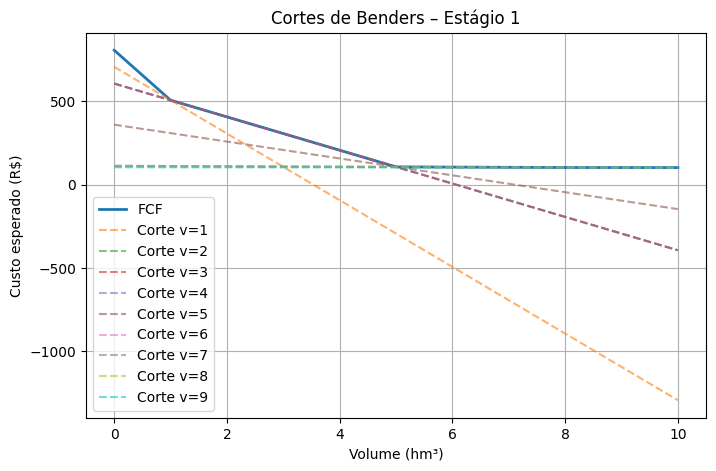

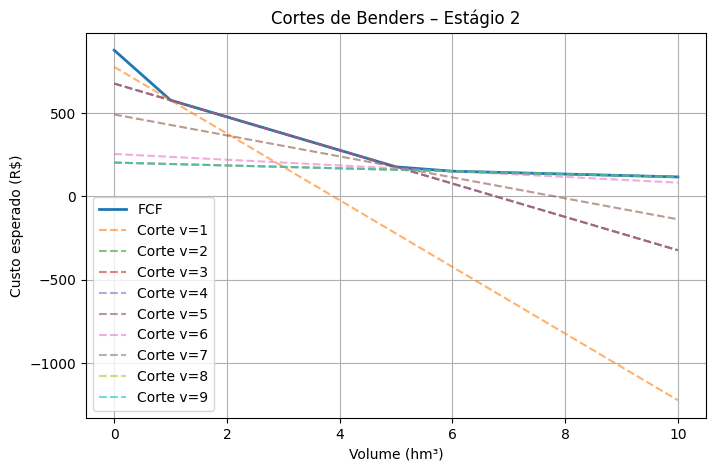

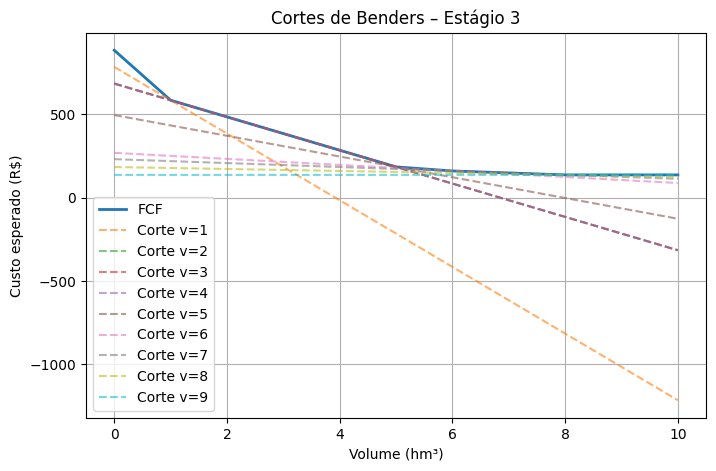

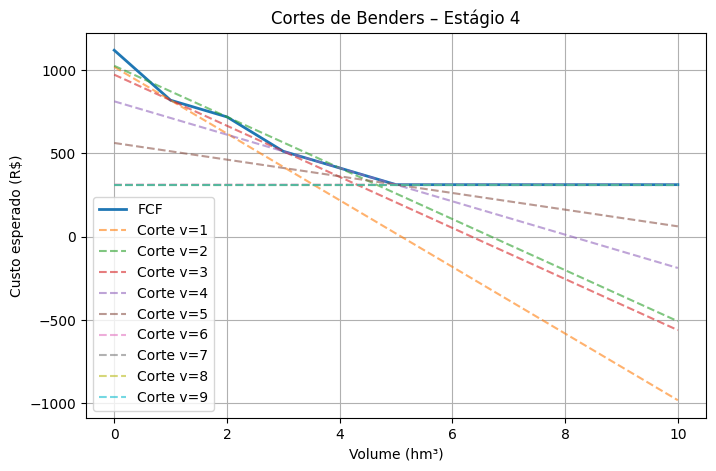

Não há cortes no estágio 5. Estágio terminal.


In [14]:
for estagio in range(1, dadger["estagios"] + 1):
    plot_cortes(dadger, estagio, cortes, fcf)

#### CMO


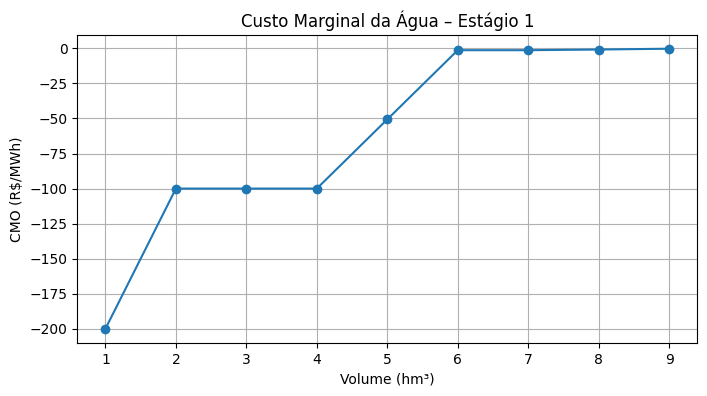

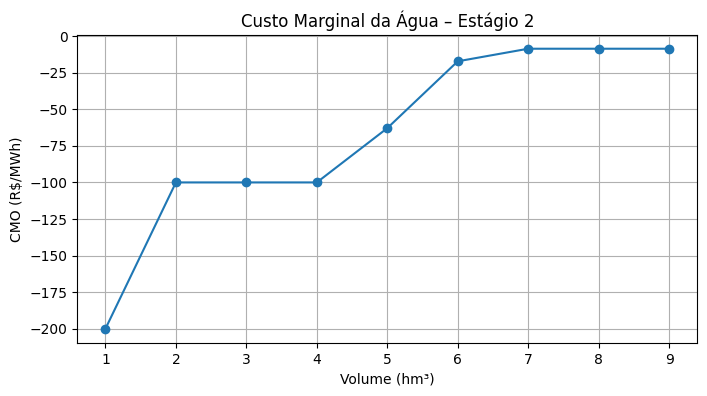

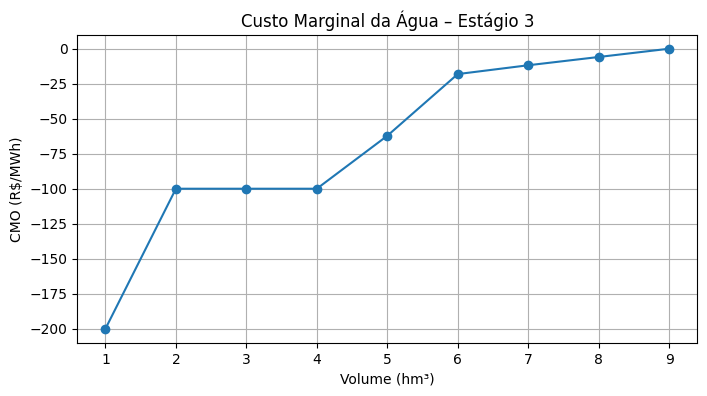

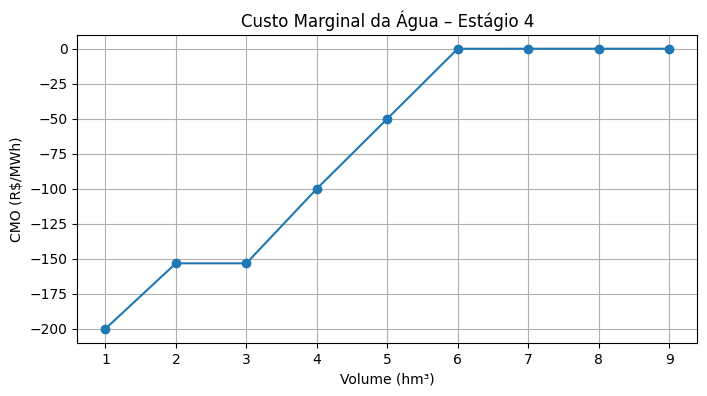

Não é possível calcular CMO no estágio 5.


In [15]:
for estagio in range(1, dadger["estagios"] + 1):
    plot_cmo(dadger, estagio, cortes)

#### Simulação


##### Individual


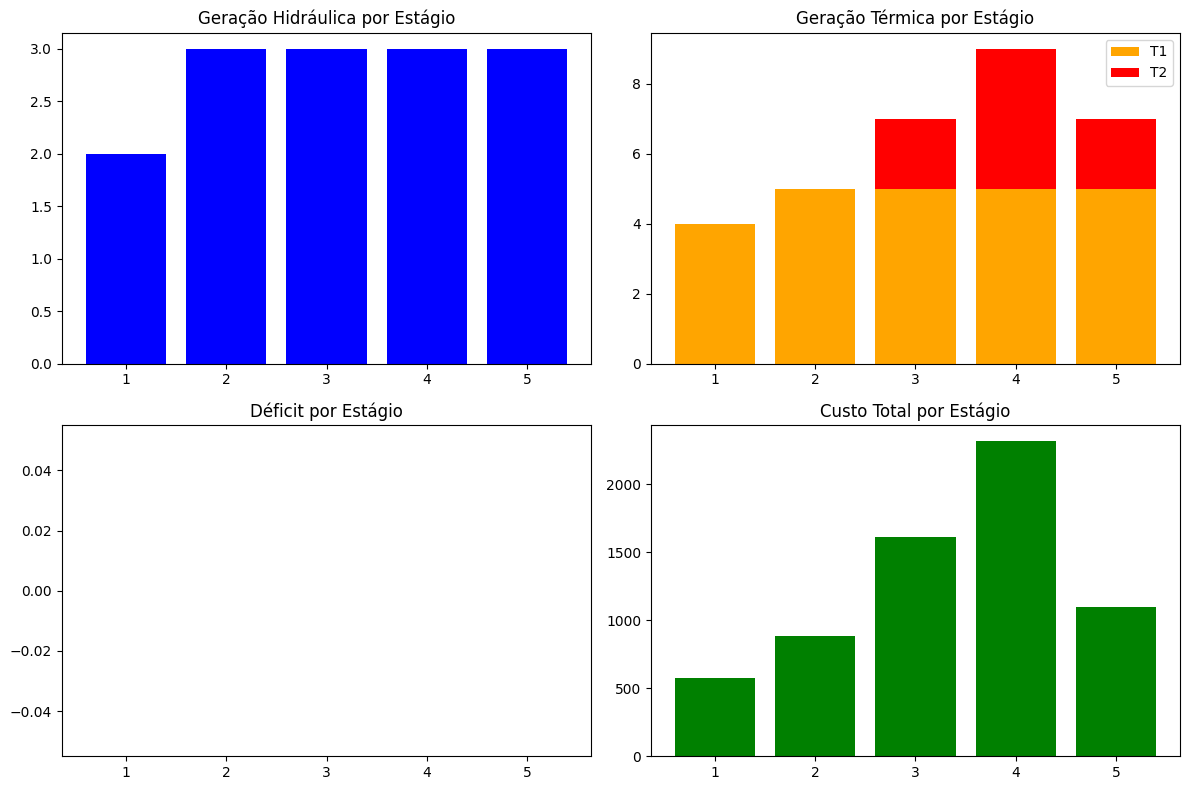

In [16]:
resultados = forward(dadger, fcf)
plot_forward(resultados)

##### Monte Carlo


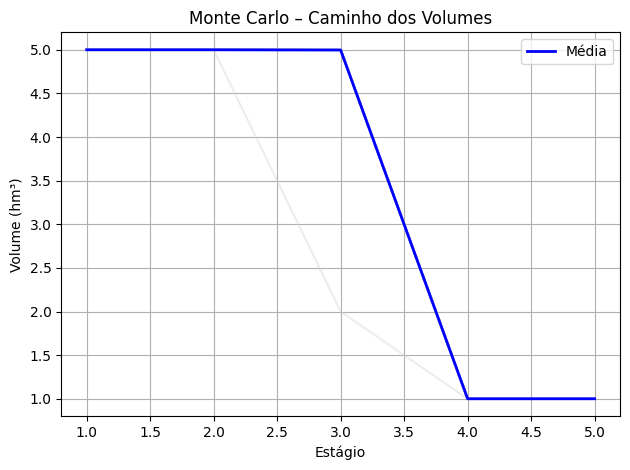

In [17]:
plot_volumes(vols)